<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

In [4]:
median_price = df["price"].median()
df["expensive"] = (df["price"] > median_price).astype(int)

yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in yes_no_cols:
    df[col] = (df[col] == "yes").astype(int)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True, dtype=int)

feature_cols = [c for c in df.columns if c not in ("price", "expensive")]
X_all = df[feature_cols].values.astype(float)
Y_all = df["expensive"].values.reshape(-1, 1).astype(float)
n_x = X_all.shape[1]

print("n_x (features):", n_x, " total examples:", X_all.shape[0])
print("Feature columns:", feature_cols)

n_x (features): 13  total examples: 545
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid_derivative(a):
    return a * (1 - a)

def compute_cost(AL, Y, eps=1e-8):
    m = Y.shape[1]
    ALc = np.clip(AL, eps, 1 - eps)
    return np.squeeze(-(1.0 / m) * np.sum(Y * np.log(ALc) + (1 - Y) * np.log(1 - ALc)))

def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        Z = np.dot(parameters[f"W{l}"], A_prev) + parameters[f"b{l}"]
        A = relu(Z)
        caches.append((A_prev, parameters[f"W{l}"], parameters[f"b{l}"], Z))
    ZL = np.dot(parameters[f"W{L}"], A) + parameters[f"b{L}"]
    AL = sigmoid(ZL)
    caches.append((A, parameters[f"W{L}"], parameters[f"b{L}"], ZL))
    return AL, caches

def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    dAL = -(np.divide(Y, np.clip(AL, 1e-8, 1)) - np.divide(1 - Y, np.clip(1 - AL, 1e-8, 1)))

    A_prev, W, b, Z = caches[L - 1]
    m = A_prev.shape[1]
    dZ = dAL * sigmoid_derivative(AL)
    grads[f"dW{L}"] = (1.0/m) * np.dot(dZ, A_prev.T)
    grads[f"db{L}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
    dA = np.dot(W.T, dZ)

    for l in reversed(range(1, L)):
        A_prev, W, b, Z = caches[l - 1]
        m = A_prev.shape[1]
        dZ = dA * relu_derivative(Z)
        grads[f"dW{l}"] = (1.0/m) * np.dot(dZ, A_prev.T)
        grads[f"db{l}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
        dA = np.dot(W.T, dZ)

    return grads

def predict_deep(parameters, X, threshold=0.5):
    AL, _ = L_model_forward(X, parameters)
    return (AL > threshold).astype(int)

print("Core network functions defined.")

Core network functions defined.


## 1. Normalizing Inputs

Raw features live on wildly different scales — house `area` is in the thousands while `bedrooms` is a single digit. Gradient descent struggles with this: the cost surface becomes a long, narrow valley, so a learning rate small enough to be stable along the steep direction is far too small along the shallow direction.

Normalization (standardization) fixes this in two steps, using **training-set statistics only**:

$$\mu = \frac{1}{m}\sum x^{(i)}, \qquad x := x - \mu$$
$$\sigma^2 = \frac{1}{m}\sum (x^{(i)})^2, \qquad x := \frac{x}{\sigma}$$

The same $\mu$ and $\sigma$ must then be applied to dev/test data — never recomputed on them, or the model would see differently-scaled inputs than it trained on.

In [6]:
# Look at the raw scale problem first
raw_stats = pd.DataFrame({
    "feature": feature_cols,
    "mean": X_all.mean(axis=0),
    "std": X_all.std(axis=0),
    "min": X_all.min(axis=0),
    "max": X_all.max(axis=0),
})
print("BEFORE normalization (note how 'area' dwarfs everything else):")
print(raw_stats.to_string(index=False))

BEFORE normalization (note how 'area' dwarfs everything else):
                        feature        mean         std    min     max
                           area 5150.541284 2168.149153 1650.0 16200.0
                       bedrooms    2.965138    0.737386    1.0     6.0
                      bathrooms    1.286239    0.502008    1.0     4.0
                        stories    1.805505    0.866696    1.0     4.0
                       mainroad    0.858716    0.348315    0.0     1.0
                      guestroom    0.177982    0.382497    0.0     1.0
                       basement    0.350459    0.477114    0.0     1.0
                hotwaterheating    0.045872    0.209207    0.0     1.0
                airconditioning    0.315596    0.464753    0.0     1.0
                        parking    0.693578    0.860795    0.0     3.0
                       prefarea    0.234862    0.423913    0.0     1.0
furnishingstatus_semi-furnished    0.416514    0.492981    0.0     1.0
   furnishings

In [7]:
def split_and_normalize(X_all, Y_all, train_frac=0.6, dev_frac=0.2, seed=42, normalize=True):
    m_total = X_all.shape[0]
    perm = np.random.RandomState(seed).permutation(m_total)
    n_train, n_dev = int(train_frac * m_total), int(dev_frac * m_total)
    tr, dv, te = perm[:n_train], perm[n_train:n_train+n_dev], perm[n_train+n_dev:]

    if normalize:
        mu = X_all[tr].mean(axis=0, keepdims=True)         # TRAIN statistics only
        sigma = X_all[tr].std(axis=0, keepdims=True) + 1e-8
    else:
        mu, sigma = 0.0, 1.0

    X_train = ((X_all[tr] - mu) / sigma).T
    X_dev   = ((X_all[dv] - mu) / sigma).T
    X_test  = ((X_all[te] - mu) / sigma).T
    return X_train, Y_all[tr].T, X_dev, Y_all[dv].T, X_test, Y_all[te].T

X_train, Y_train, X_dev, Y_dev, X_test, Y_test = split_and_normalize(X_all, Y_all)
X_train_un, Y_train_un, X_dev_un, Y_dev_un, _, _ = split_and_normalize(X_all, Y_all, normalize=False)

print("AFTER normalization - every feature now has mean~0, std~1:")
print("  means:", np.round(X_train.mean(axis=1), 4)[:5], "...")
print("  stds: ", np.round(X_train.std(axis=1), 4)[:5], "...")
print("\nShapes -> train:", X_train.shape, " dev:", X_dev.shape, " test:", X_test.shape)

AFTER normalization - every feature now has mean~0, std~1:
  means: [0. 0. 0. 0. 0.] ...
  stds:  [1. 1. 1. 1. 1.] ...

Shapes -> train: (13, 327)  dev: (13, 109)  test: (13, 109)


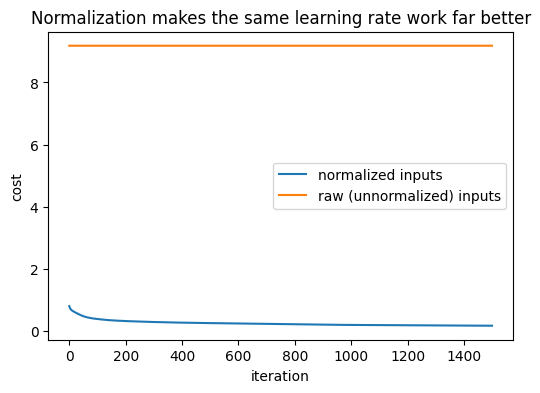

Final cost, normalized:   0.1772
Final cost, unnormalized: 9.1822


In [8]:
def initialize_parameters_deep(layer_dims, seed=1, init_type="he"):
    rng = np.random.RandomState(seed)
    parameters = {}
    L = len(layer_dims) - 1
    for l in range(1, L + 1):
        fan_in = layer_dims[l-1]
        if init_type == "he":          # good for ReLU
            scale = np.sqrt(2.0 / fan_in)
        elif init_type == "xavier":    # good for tanh/sigmoid
            scale = np.sqrt(1.0 / fan_in)
        elif init_type == "small":     # naive fixed small constant
            scale = 0.01
        elif init_type == "large":     # deliberately too big
            scale = 1.5
        else:
            raise ValueError("unknown init_type")
        parameters[f"W{l}"] = rng.randn(layer_dims[l], layer_dims[l-1]) * scale
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
    return parameters

def update_parameters_gd(parameters, grads, alpha):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f"W{l}"] -= alpha * grads[f"dW{l}"]
        parameters[f"b{l}"] -= alpha * grads[f"db{l}"]
    return parameters

def train_basic(X, Y, layer_dims, num_iterations=1500, alpha=0.1, seed=1, init_type="he"):
    params = initialize_parameters_deep(layer_dims, seed=seed, init_type=init_type)
    costs = []
    for it in range(num_iterations):
        AL, caches = L_model_forward(X, params)
        costs.append(compute_cost(AL, Y))
        grads = L_model_backward(AL, Y, caches)
        params = update_parameters_gd(params, grads, alpha)
    return params, costs

# Same network, same learning rate -- only difference is whether inputs were normalized
dims = [n_x, 10, 5, 1]
_, costs_norm   = train_basic(X_train,    Y_train,    dims, num_iterations=1500, alpha=0.1)
_, costs_unnorm = train_basic(X_train_un, Y_train_un, dims, num_iterations=1500, alpha=0.1)

plt.figure(figsize=(6, 4))
plt.plot(costs_norm, label="normalized inputs")
plt.plot(costs_unnorm, label="raw (unnormalized) inputs")
plt.xlabel("iteration"); plt.ylabel("cost"); plt.legend()
plt.title("Normalization makes the same learning rate work far better")
plt.show()

print(f"Final cost, normalized:   {costs_norm[-1]:.4f}")
print(f"Final cost, unnormalized: {costs_unnorm[-1]:.4f}")

## 2. Vanishing / Exploding Gradients

In a deep network, the signal passes through many weight matrices in sequence. Roughly, activations and gradients get multiplied by something like $W^{[L]}W^{[L-1]}\cdots W^{[1]}$. If each weight matrix scales its input by a factor slightly **greater than 1**, that factor compounds exponentially with depth and activations/gradients **explode**; if slightly **less than 1**, they shrink exponentially and **vanish**.

With vanishing gradients, early layers receive almost no gradient signal and effectively stop learning. With exploding gradients, updates become enormous and training diverges (or produces `NaN`).

Below: build deep networks with deliberately too-small and too-large initialization, and measure how activation magnitude and gradient magnitude change layer by layer.

In [9]:
def inspect_signal_flow(layer_dims, X, Y, init_type, seed=1):
    """Measure activation and gradient magnitude at each layer for a given initialization."""
    params = initialize_parameters_deep(layer_dims, seed=seed, init_type=init_type)
    AL, caches = L_model_forward(X, params)
    grads = L_model_backward(AL, Y, caches)

    act_norms = [np.sqrt(np.mean(np.square(c[3]))) for c in caches]     # RMS of Z at each layer
    grad_norms = [np.sqrt(np.mean(np.square(grads[f"dW{l}"]))) for l in range(1, len(layer_dims))]
    return act_norms, grad_norms

deep_dims = [n_x] + [10] * 8 + [1]   # a deliberately deep network: 9 layers

print(f"{'init':>8} | {'layer':>5} | {'RMS activation (Z)':>19} | {'RMS gradient (dW)':>18}")
print("-" * 60)
for init_type in ["small", "large", "he"]:
    acts, grads_n = inspect_signal_flow(deep_dims, X_train, Y_train, init_type)
    for l in [0, 3, 6, len(acts)-1]:
        print(f"{init_type:>8} | {l+1:>5} | {acts[l]:>19.3e} | {grads_n[l]:>18.3e}")
    print("-" * 60)

    init | layer |  RMS activation (Z) |  RMS gradient (dW)
------------------------------------------------------------
   small |     1 |           3.390e-02 |          3.310e-16
   small |     4 |           4.332e-07 |          6.299e-16
   small |     7 |           5.340e-12 |          2.212e-16
   small |     9 |           5.111e-16 |          3.251e-15
------------------------------------------------------------
   large |     1 |           5.085e+00 |          0.000e+00
   large |     4 |           2.193e+02 |          0.000e+00
   large |     7 |           9.123e+03 |          0.000e+00
   large |     9 |           1.965e+04 |          0.000e+00
------------------------------------------------------------
      he |     1 |           1.330e+00 |          5.151e-03
      he |     4 |           1.520e+00 |          8.888e-03
      he |     7 |           1.675e+00 |          2.988e-03
      he |     9 |           3.208e-01 |          1.247e-02
-------------------------------------

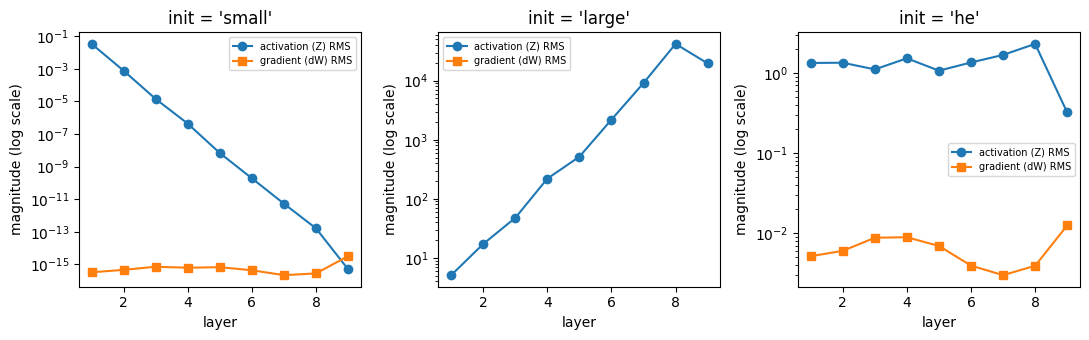

'small' (W*0.01): signal shrinks toward zero with depth -> VANISHING
'large' (W*1.5):  signal grows rapidly with depth       -> EXPLODING
'he':             signal stays roughly stable            -> healthy


In [10]:
# Visualize the exponential compounding across depth
plt.figure(figsize=(11, 3.5))
for i, init_type in enumerate(["small", "large", "he"], start=1):
    acts, grads_n = inspect_signal_flow(deep_dims, X_train, Y_train, init_type)
    plt.subplot(1, 3, i)
    plt.semilogy(range(1, len(acts)+1), acts, marker="o", label="activation (Z) RMS")
    plt.semilogy(range(1, len(grads_n)+1), grads_n, marker="s", label="gradient (dW) RMS")
    plt.title(f"init = '{init_type}'")
    plt.xlabel("layer"); plt.ylabel("magnitude (log scale)")
    plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

print("'small' (W*0.01): signal shrinks toward zero with depth -> VANISHING")
print("'large' (W*1.5):  signal grows rapidly with depth       -> EXPLODING")
print("'he':             signal stays roughly stable            -> healthy")

## 3. Weight Initialization in a Deep Network

The fix for the above is to scale initial weights based on the number of inputs to each layer ($n^{[l-1]}$, the "fan-in"), so the variance of the output roughly matches the variance of the input, preventing compounding:

- **He initialization** (for ReLU): $W^{[l]} \sim \mathcal{N}(0,1) \times \sqrt{\dfrac{2}{n^{[l-1]}}}$ — the factor 2 compensates for ReLU zeroing out roughly half its inputs.
- **Xavier / Glorot initialization** (for tanh/sigmoid): $W^{[l]} \sim \mathcal{N}(0,1) \times \sqrt{\dfrac{1}{n^{[l-1]}}}$

Biases can safely start at zero. Below: train the same deep network with each initialization scheme and compare how well they actually learn.

 init type |  final cost | dev accuracy
----------------------------------------
     small |      0.6931 |        51.4%
     large |      9.1822 |        51.4%
        he |      0.1085 |        78.0%
    xavier |      0.0873 |        79.8%


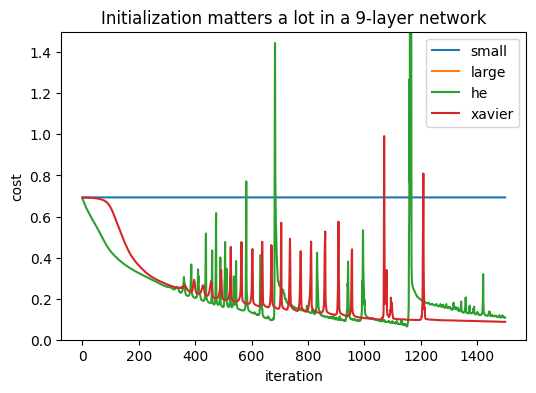

In [11]:
init_types = ["small", "large", "he", "xavier"]
plt.figure(figsize=(6, 4))
print(f"{'init type':>10} | {'final cost':>11} | {'dev accuracy':>12}")
print("-" * 40)
for init_type in init_types:
    params_i, costs_i = train_basic(X_train, Y_train, deep_dims,
                                     num_iterations=1500, alpha=0.1, init_type=init_type)
    dev_acc = np.mean(predict_deep(params_i, X_dev) == Y_dev) * 100
    print(f"{init_type:>10} | {costs_i[-1]:>11.4f} | {dev_acc:>11.1f}%")
    plt.plot(costs_i, label=f"{init_type}")

plt.xlabel("iteration"); plt.ylabel("cost"); plt.legend()
plt.title(f"Initialization matters a lot in a {len(deep_dims)-1}-layer network")
plt.ylim(0, 1.5)
plt.show()

## 4. Numerical Approximations of Gradients

Before trusting a hand-written backprop implementation, you can approximate any derivative numerically and compare. The **two-sided** (centered) difference is far more accurate than the one-sided version:

$$\text{one-sided: } \frac{f(\theta+\varepsilon) - f(\theta)}{\varepsilon} \quad \text{error } O(\varepsilon)$$
$$\text{two-sided: } \frac{f(\theta+\varepsilon) - f(\theta-\varepsilon)}{2\varepsilon} \quad \text{error } O(\varepsilon^2)$$

With $\varepsilon = 10^{-7}$, the two-sided version's error is roughly $10^{-14}$ versus $10^{-7}$ — a huge difference when you're trying to detect a genuine bug versus normal floating-point noise.

In [12]:
def f_demo(theta):
    return theta ** 3

def f_prime_exact(theta):
    return 3 * theta ** 2

theta = 2.0
exact = f_prime_exact(theta)

print(f"Exact derivative at theta={theta}: {exact}\n")
print(f"{'epsilon':>10} | {'one-sided':>14} | {'one-sided err':>14} | {'two-sided':>14} | {'two-sided err':>14}")
print("-" * 80)
for eps in [1e-2, 1e-4, 1e-7]:
    one_sided = (f_demo(theta + eps) - f_demo(theta)) / eps
    two_sided = (f_demo(theta + eps) - f_demo(theta - eps)) / (2 * eps)
    print(f"{eps:>10.0e} | {one_sided:>14.8f} | {abs(one_sided-exact):>14.2e} | {two_sided:>14.8f} | {abs(two_sided-exact):>14.2e}")

print("\n-> The two-sided difference is dramatically more accurate at every epsilon.")

Exact derivative at theta=2.0: 12.0

   epsilon |      one-sided |  one-sided err |      two-sided |  two-sided err
--------------------------------------------------------------------------------
     1e-02 |    12.06010000 |       6.01e-02 |    12.00010000 |       1.00e-04
     1e-04 |    12.00060001 |       6.00e-04 |    12.00000001 |       1.00e-08
     1e-07 |    12.00000058 |       5.84e-07 |    11.99999999 |       6.32e-09

-> The two-sided difference is dramatically more accurate at every epsilon.


## 5. Gradient Checking

Gradient checking verifies an entire backprop implementation at once:

1. Flatten every parameter ($W^{[1]}, b^{[1]}, \dots$) into one big vector $\theta$.
2. Flatten every gradient the same way into $d\theta$.
3. For each entry $i$, compute the numerical gradient $d\theta_{approx}[i] = \dfrac{J(\theta \text{ with } \theta_i+\varepsilon) - J(\theta \text{ with } \theta_i-\varepsilon)}{2\varepsilon}$.
4. Compare with the **relative** difference (scale-independent, unlike an absolute difference):

$$\text{difference} = \frac{\|d\theta_{approx} - d\theta\|_2}{\|d\theta_{approx}\|_2 + \|d\theta\|_2}$$

**Interpreting the result** (with $\varepsilon = 10^{-7}$): $< 10^{-7}$ is great, around $10^{-5}$ is borderline (worth inspecting), and $> 10^{-3}$ almost certainly means a bug.

In [13]:
def dictionary_to_vector(parameters):
    """Flatten all parameters into a single column vector, remembering shapes for the reverse operation."""
    keys, theta = [], []
    L = len(parameters) // 2
    for l in range(1, L + 1):
        for prefix in ["W", "b"]:
            key = f"{prefix}{l}"
            keys.append((key, parameters[key].shape))
            theta.append(parameters[key].reshape(-1, 1))
    return np.concatenate(theta, axis=0), keys

def vector_to_dictionary(theta, keys):
    parameters = {}
    idx = 0
    for key, shape in keys:
        size = shape[0] * shape[1]
        parameters[key] = theta[idx:idx+size].reshape(shape)
        idx += size
    return parameters

def gradients_to_vector(grads, keys):
    theta = []
    for key, shape in keys:
        theta.append(grads["d" + key].reshape(-1, 1))
    return np.concatenate(theta, axis=0)

def gradient_check(parameters, X, Y, epsilon=1e-7, verbose=True):
    theta, keys = dictionary_to_vector(parameters)

    AL, caches = L_model_forward(X, parameters)
    grads = L_model_backward(AL, Y, caches)
    dtheta = gradients_to_vector(grads, keys)

    num_params = theta.shape[0]
    dtheta_approx = np.zeros((num_params, 1))

    for i in range(num_params):
        theta_plus = np.copy(theta)
        theta_plus[i] += epsilon
        AL_plus, _ = L_model_forward(X, vector_to_dictionary(theta_plus, keys))
        J_plus = compute_cost(AL_plus, Y)

        theta_minus = np.copy(theta)
        theta_minus[i] -= epsilon
        AL_minus, _ = L_model_forward(X, vector_to_dictionary(theta_minus, keys))
        J_minus = compute_cost(AL_minus, Y)

        dtheta_approx[i] = (J_plus - J_minus) / (2 * epsilon)

    numerator = np.linalg.norm(dtheta_approx - dtheta)
    denominator = np.linalg.norm(dtheta_approx) + np.linalg.norm(dtheta)
    difference = numerator / denominator

    if verbose:
        if difference < 1e-7:
            verdict = "PASS - backprop looks correct"
        elif difference < 1e-5:
            verdict = "BORDERLINE - inspect carefully"
        else:
            verdict = "FAIL - there is likely a bug"
        print(f"Checked {num_params} parameters. Relative difference = {difference:.3e}  -> {verdict}")

    return difference

# Check on a SMALL network and a SMALL data subset (gradient checking is expensive)
small_dims = [n_x, 5, 3, 1]
params_gc = initialize_parameters_deep(small_dims, seed=3)
_ = gradient_check(params_gc, X_train[:, :20], Y_train[:, :20])

Checked 92 parameters. Relative difference = 4.011e-09  -> PASS - backprop looks correct


In [14]:
# Now deliberately BREAK backprop, and confirm gradient checking catches it
def L_model_backward_buggy(AL, Y, caches):
    """Identical to L_model_backward, except one subtle bug: missing the 1/m factor on dW1."""
    grads = L_model_backward(AL, Y, caches)
    grads["dW1"] = grads["dW1"] * Y.shape[1]   # <-- BUG introduced here
    return grads

def gradient_check_with(backward_fn, parameters, X, Y, epsilon=1e-7):
    theta, keys = dictionary_to_vector(parameters)
    AL, caches = L_model_forward(X, parameters)
    grads = backward_fn(AL, Y, caches)
    dtheta = gradients_to_vector(grads, keys)

    dtheta_approx = np.zeros_like(theta)
    for i in range(theta.shape[0]):
        tp, tm = np.copy(theta), np.copy(theta)
        tp[i] += epsilon; tm[i] -= epsilon
        ALp, _ = L_model_forward(X, vector_to_dictionary(tp, keys))
        ALm, _ = L_model_forward(X, vector_to_dictionary(tm, keys))
        dtheta_approx[i] = (compute_cost(ALp, Y) - compute_cost(ALm, Y)) / (2 * epsilon)

    return np.linalg.norm(dtheta_approx - dtheta) / (np.linalg.norm(dtheta_approx) + np.linalg.norm(dtheta))

diff_correct = gradient_check_with(L_model_backward,       params_gc, X_train[:, :20], Y_train[:, :20])
diff_buggy   = gradient_check_with(L_model_backward_buggy, params_gc, X_train[:, :20], Y_train[:, :20])

print(f"Correct backprop: difference = {diff_correct:.3e}  -> PASS")
print(f"Buggy backprop:   difference = {diff_buggy:.3e}  -> FAIL (caught the bug!)")

Correct backprop: difference = 4.011e-09  -> PASS
Buggy backprop:   difference = 8.469e-01  -> FAIL (caught the bug!)


## 6. Gradient Checking Implementation Notes

Practical rules for using gradient checking correctly:

- **Only use it to debug, never during training.** Computing $d\theta_{approx}$ requires two full forward passes *per parameter* — thousands of times slower than backprop. Run it once to verify, then turn it off.
- **If it fails, look at individual components** to find which layer is wrong, rather than just knowing "something" is broken.
- **Remember the regularization term.** If your cost includes an L2 penalty, the gradient must include $\frac{\lambda}{m}W$ — check the regularized cost against the regularized gradient, or they won't match.
- **Doesn't work with dropout.** Dropout makes the cost random (different mask each call), so $J$ isn't a fixed function. Turn dropout off (`keep_prob = 1.0`) while checking, or fix the random seed so the same mask is reused.
- **Run it after a few iterations of training**, not only at initialization. Some bugs only appear once weights have moved away from their initial small values.

Below: a demonstration of the regularization pitfall — checking a regularized cost against unregularized gradients fails, and matching them correctly passes.

In [15]:
def compute_cost_l2(AL, Y, parameters, lambd):
    m = Y.shape[1]
    L = len(parameters) // 2
    weight_sum = sum(np.sum(np.square(parameters[f"W{l}"])) for l in range(1, L+1))
    return compute_cost(AL, Y) + (lambd / (2*m)) * weight_sum

def L_model_backward_l2(AL, Y, caches, parameters, lambd):
    grads = L_model_backward(AL, Y, caches)
    m = Y.shape[1]
    for l in range(1, len(caches) + 1):
        grads[f"dW{l}"] += (lambd / m) * parameters[f"W{l}"]
    return grads

def gradient_check_l2(parameters, X, Y, lambd, use_l2_in_grads, epsilon=1e-7):
    theta, keys = dictionary_to_vector(parameters)
    AL, caches = L_model_forward(X, parameters)

    if use_l2_in_grads:
        grads = L_model_backward_l2(AL, Y, caches, parameters, lambd)
    else:
        grads = L_model_backward(AL, Y, caches)   # forgot the regularization term!
    dtheta = gradients_to_vector(grads, keys)

    dtheta_approx = np.zeros_like(theta)
    for i in range(theta.shape[0]):
        tp, tm = np.copy(theta), np.copy(theta)
        tp[i] += epsilon; tm[i] -= epsilon
        pp, pm = vector_to_dictionary(tp, keys), vector_to_dictionary(tm, keys)
        ALp, _ = L_model_forward(X, pp)
        ALm, _ = L_model_forward(X, pm)
        # the COST here includes the L2 term, so the gradients must too
        dtheta_approx[i] = (compute_cost_l2(ALp, Y, pp, lambd) - compute_cost_l2(ALm, Y, pm, lambd)) / (2*epsilon)

    return np.linalg.norm(dtheta_approx - dtheta) / (np.linalg.norm(dtheta_approx) + np.linalg.norm(dtheta))

lambd = 0.7
diff_forgot  = gradient_check_l2(params_gc, X_train[:, :20], Y_train[:, :20], lambd, use_l2_in_grads=False)
diff_correct = gradient_check_l2(params_gc, X_train[:, :20], Y_train[:, :20], lambd, use_l2_in_grads=True)

print(f"L2 cost vs UNregularized gradients: difference = {diff_forgot:.3e}  -> FAIL (forgot lambda/m * W)")
print(f"L2 cost vs L2 gradients:            difference = {diff_correct:.3e}  -> PASS")

L2 cost vs UNregularized gradients: difference = 6.164e-02  -> FAIL (forgot lambda/m * W)
L2 cost vs L2 gradients:            difference = 4.177e-09  -> PASS


## 7. Mini-Batch Gradient Descent

So far every update used **all** `m` training examples (batch gradient descent). With large datasets that's slow — you wait for a full pass over millions of examples just to take one step.

**Mini-batch** gradient descent splits the training set into small batches (typically 64, 128, 256, 512) and takes one update per batch. One pass through all mini-batches is called an **epoch**.

- Batch size = $m$ -> batch gradient descent (smooth cost curve, slow per step)
- Batch size = 1 -> **stochastic** gradient descent (very noisy, loses all vectorization benefit)
- Batch size in between -> mini-batch (the practical sweet spot)

Shuffle before partitioning each epoch, so batches differ between epochs.

In [16]:
def random_mini_batches(X, Y, mini_batch_size=64, seed=0):
    """Shuffle, then partition into mini-batches (the last one may be smaller)."""
    rng = np.random.RandomState(seed)
    m = X.shape[1]
    mini_batches = []

    permutation = list(rng.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((Y.shape[0], m))

    num_complete = math.floor(m / mini_batch_size)
    for k in range(num_complete):
        mb_X = shuffled_X[:, k*mini_batch_size:(k+1)*mini_batch_size]
        mb_Y = shuffled_Y[:, k*mini_batch_size:(k+1)*mini_batch_size]
        mini_batches.append((mb_X, mb_Y))

    if m % mini_batch_size != 0:   # handle the leftover partial batch
        mb_X = shuffled_X[:, num_complete*mini_batch_size:]
        mb_Y = shuffled_Y[:, num_complete*mini_batch_size:]
        mini_batches.append((mb_X, mb_Y))

    return mini_batches

batches = random_mini_batches(X_train, Y_train, mini_batch_size=64, seed=0)
print(f"Training set has {X_train.shape[1]} examples -> {len(batches)} mini-batches of size <= 64")
for i, (bx, by) in enumerate(batches):
    print(f"  batch {i}: X{bx.shape}, Y{by.shape}")

Training set has 327 examples -> 6 mini-batches of size <= 64
  batch 0: X(13, 64), Y(1, 64)
  batch 1: X(13, 64), Y(1, 64)
  batch 2: X(13, 64), Y(1, 64)
  batch 3: X(13, 64), Y(1, 64)
  batch 4: X(13, 64), Y(1, 64)
  batch 5: X(13, 7), Y(1, 7)


## 8. Understanding Mini-Batch Gradient Descent

The trade-off is **noise vs. speed**:

- **Batch** (size $m$): every step uses the true gradient, so cost decreases smoothly and monotonically — but each step is expensive.
- **Stochastic** (size 1): each step is based on one example, so the cost bounces around wildly and never truly settles; it also wastes vectorization entirely.
- **Mini-batch**: cost decreases with visible noise (each batch's gradient is only an estimate of the true gradient), but progresses much faster in wall-clock terms and the noise can even help escape shallow local minima.

Below: train the same network with all three batch sizes and compare both the cost curves and the actual time taken.

   batch (m=327): final cost = 0.3275, dev acc = 85.3%, time = 0.15s
 mini-batch (64): final cost = 0.2094, dev acc = 78.9%, time = 0.32s
  stochastic (1): final cost = 0.7472, dev acc = 50.5%, time = 12.13s


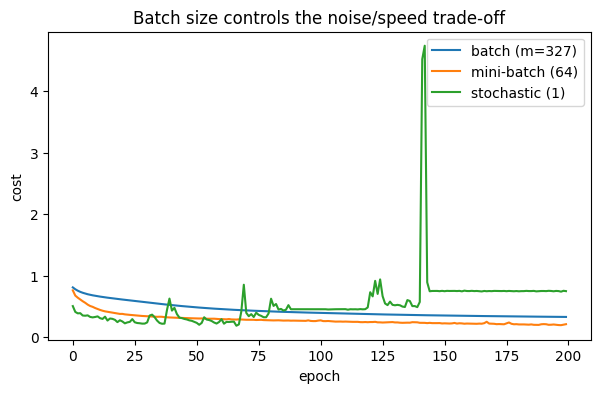

In [17]:
def train_minibatch(X, Y, layer_dims, mini_batch_size, num_epochs=200, alpha=0.1, seed=1):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    costs = []
    t_start = time.time()
    for epoch in range(num_epochs):
        batches = random_mini_batches(X, Y, mini_batch_size, seed=epoch)
        epoch_cost = 0.0
        for (mb_X, mb_Y) in batches:
            AL, caches = L_model_forward(mb_X, params)
            epoch_cost += compute_cost(AL, mb_Y) * mb_X.shape[1]
            grads = L_model_backward(AL, mb_Y, caches)
            params = update_parameters_gd(params, grads, alpha)
        costs.append(epoch_cost / X.shape[1])
    elapsed = time.time() - t_start
    return params, costs, elapsed

dims_mb = [n_x, 10, 5, 1]
m_train = X_train.shape[1]

results = {}
for name, bs in [("batch (m=327)", m_train), ("mini-batch (64)", 64), ("stochastic (1)", 1)]:
    p, c, t = train_minibatch(X_train, Y_train, dims_mb, bs, num_epochs=200, alpha=0.1)
    acc = np.mean(predict_deep(p, X_dev) == Y_dev) * 100
    results[name] = c
    print(f"{name:>16}: final cost = {c[-1]:.4f}, dev acc = {acc:.1f}%, time = {t:.2f}s")

plt.figure(figsize=(7, 4))
for name, c in results.items():
    plt.plot(c, label=name)
plt.xlabel("epoch"); plt.ylabel("cost"); plt.legend()
plt.title("Batch size controls the noise/speed trade-off")
plt.show()

## 9. Exponentially Weighted Averages

Before momentum/RMSProp/Adam, we need the idea they all share. An **exponentially weighted (moving) average** smooths a noisy sequence:

$$v_t = \beta v_{t-1} + (1-\beta)\theta_t$$

Intuitively, $v_t$ averages over roughly the last $\dfrac{1}{1-\beta}$ values:

- $\beta = 0.9$ -> averages over ~10 values (responsive, still a bit noisy)
- $\beta = 0.98$ -> averages over ~50 values (very smooth, but lags behind changes)
- $\beta = 0.5$ -> averages over ~2 values (barely smooths at all)

Below, applied to a noisy synthetic "temperature" series so the smoothing effect is easy to see.

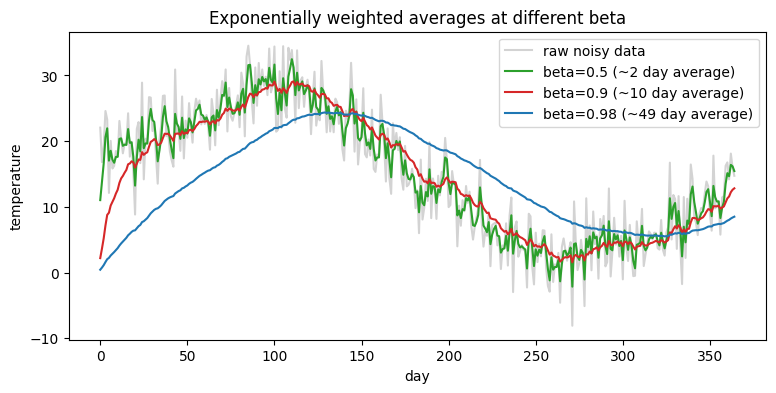

In [18]:
# Noisy synthetic series (like daily temperatures over a year)
days = np.arange(365)
true_signal = 15 + 12 * np.sin(2 * np.pi * days / 365)
rng = np.random.RandomState(0)
temps = true_signal + rng.randn(365) * 4

def exponentially_weighted_average(data, beta):
    v = 0.0
    out = []
    for theta in data:
        v = beta * v + (1 - beta) * theta
        out.append(v)
    return np.array(out)

plt.figure(figsize=(9, 4))
plt.plot(days, temps, color="lightgray", label="raw noisy data")
for beta, color in [(0.5, "tab:green"), (0.9, "tab:red"), (0.98, "tab:blue")]:
    plt.plot(days, exponentially_weighted_average(temps, beta), color=color,
             label=f"beta={beta} (~{int(1/(1-beta))} day average)")
plt.xlabel("day"); plt.ylabel("temperature"); plt.legend()
plt.title("Exponentially weighted averages at different beta")
plt.show()

## 10. Understanding Exponentially Weighted Averages

Expanding the recursion shows why it's called *exponentially* weighted:

$$v_t = (1-\beta)\theta_t + (1-\beta)\beta\,\theta_{t-1} + (1-\beta)\beta^2\theta_{t-2} + \cdots$$

Each older value is weighted by an extra factor of $\beta$, so weights **decay exponentially** into the past. Since $\beta^{1/(1-\beta)} \approx \frac{1}{e} \approx 0.37$, values older than about $\frac{1}{1-\beta}$ steps contribute less than a third as much — which is exactly where the "averages over $\frac{1}{1-\beta}$ values" rule of thumb comes from.

A big practical advantage: it needs only **one** variable in memory ($v$), regardless of how many past values it effectively averages — unlike a true moving average, which would need to store the whole window.

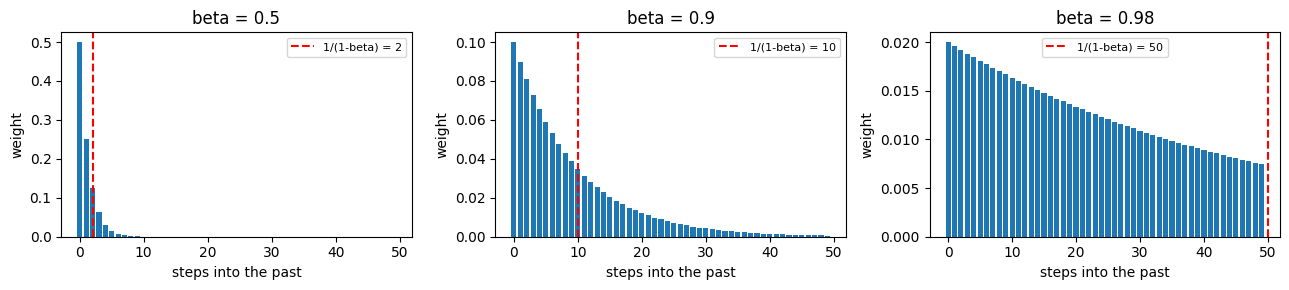

beta=0.5: weight after 2 steps = 0.2500  (compare 1/e = 0.3679)
beta=0.9: weight after 10 steps = 0.3487  (compare 1/e = 0.3679)
beta=0.98: weight after 49 steps = 0.3716  (compare 1/e = 0.3679)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, beta in zip(axes, [0.5, 0.9, 0.98]):
    lookback = 50
    weights = [(1 - beta) * (beta ** k) for k in range(lookback)]
    ax.bar(range(lookback), weights)
    ax.axvline(1/(1-beta), color="red", linestyle="--", label=f"1/(1-beta) = {1/(1-beta):.0f}")
    ax.set_title(f"beta = {beta}")
    ax.set_xlabel("steps into the past"); ax.set_ylabel("weight")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for beta in [0.5, 0.9, 0.98]:
    n = int(1/(1-beta))
    print(f"beta={beta}: weight after {n} steps = {beta**n:.4f}  (compare 1/e = {1/np.e:.4f})")

## 11. Bias Correction of Exponentially Weighted Averages

Starting from $v_0 = 0$ makes early estimates far too small — with $\beta = 0.98$, $v_1 = 0.02\,\theta_1$, only 2% of the actual first value. The fix divides by a correction factor that starts small and approaches 1:

$$v_t^{corrected} = \frac{v_t}{1 - \beta^t}$$

Early on ($t$ small), $1-\beta^t$ is small, so dividing scales the estimate up appropriately. As $t$ grows, $\beta^t \to 0$ and the correction fades away, leaving the ordinary average untouched.

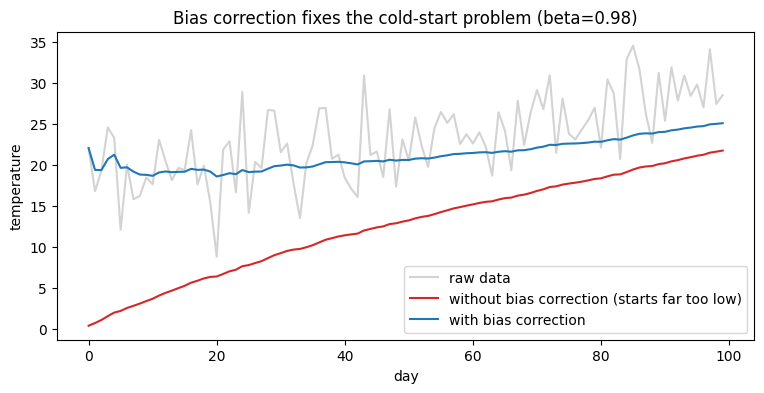

   t |  1 - beta^t |  uncorrected |  corrected | actual theta_t
--------------------------------------------------------------
   1 |      0.0200 |        0.441 |     22.056 |         22.056
   2 |      0.0396 |        0.768 |     19.405 |         16.807
   5 |      0.0961 |        2.042 |     21.256 |         23.296
  20 |      0.3324 |        6.381 |     19.198 |         15.439
 100 |      0.8674 |       21.759 |     25.085 |         28.501


In [20]:
def ewa_with_correction(data, beta, correct=True):
    v = 0.0
    out = []
    for t, theta in enumerate(data, start=1):
        v = beta * v + (1 - beta) * theta
        out.append(v / (1 - beta**t) if correct else v)
    return np.array(out)

beta = 0.98
plt.figure(figsize=(9, 4))
plt.plot(days[:100], temps[:100], color="lightgray", label="raw data")
plt.plot(days[:100], ewa_with_correction(temps, beta, correct=False)[:100],
         color="tab:red", label="without bias correction (starts far too low)")
plt.plot(days[:100], ewa_with_correction(temps, beta, correct=True)[:100],
         color="tab:blue", label="with bias correction")
plt.xlabel("day"); plt.ylabel("temperature"); plt.legend()
plt.title(f"Bias correction fixes the cold-start problem (beta={beta})")
plt.show()

print(f"{'t':>4} | {'1 - beta^t':>11} | {'uncorrected':>12} | {'corrected':>10} | {'actual theta_t':>14}")
print("-" * 62)
uncorr = ewa_with_correction(temps, beta, correct=False)
corr = ewa_with_correction(temps, beta, correct=True)
for t in [1, 2, 5, 20, 100]:
    print(f"{t:>4} | {1-beta**t:>11.4f} | {uncorr[t-1]:>12.3f} | {corr[t-1]:>10.3f} | {temps[t-1]:>14.3f}")

## 12. Gradient Descent With Momentum

Plain gradient descent oscillates across the steep direction of a narrow valley while creeping slowly along the useful direction. **Momentum** applies an exponentially weighted average to the gradients themselves, so oscillations cancel out while consistent directions accumulate:

$$v_{dW} = \beta v_{dW} + (1-\beta)\,dW, \qquad W := W - \alpha\, v_{dW}$$
$$v_{db} = \beta v_{db} + (1-\beta)\,db, \qquad b := b - \alpha\, v_{db}$$

$\beta = 0.9$ is the standard default. The physical analogy: $dW$ acts like acceleration and $v_{dW}$ like velocity — the ball rolling downhill builds up speed in consistent directions and gets damped in oscillating ones.

In [21]:
def initialize_velocity(parameters):
    v = {}
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        v[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return v

def update_parameters_momentum(parameters, grads, v, beta, alpha):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v[f"dW{l}"] = beta * v[f"dW{l}"] + (1 - beta) * grads[f"dW{l}"]
        v[f"db{l}"] = beta * v[f"db{l}"] + (1 - beta) * grads[f"db{l}"]
        parameters[f"W{l}"] -= alpha * v[f"dW{l}"]
        parameters[f"b{l}"] -= alpha * v[f"db{l}"]
    return parameters, v

print("Momentum update rule defined.")

Momentum update rule defined.


## 13. RMSProp

RMSProp (Root Mean Square propagation) tackles the same oscillation problem differently: it keeps an exponentially weighted average of the **squared** gradients, then divides each update by the square root of that average.

$$s_{dW} = \beta_2 s_{dW} + (1-\beta_2)\,dW^2, \qquad W := W - \alpha\,\frac{dW}{\sqrt{s_{dW}} + \varepsilon}$$

The effect is a **per-parameter adaptive learning rate**: parameters with consistently large gradients get divided by a large number (small steps), while parameters with small gradients get relatively larger steps. The $\varepsilon$ (typically $10^{-8}$) just prevents division by zero.

In [22]:
def initialize_rmsprop(parameters):
    s = {}
    L = len(parameters) // 2
    for l in range(1, L + 1):
        s[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        s[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return s

def update_parameters_rmsprop(parameters, grads, s, beta2, alpha, epsilon=1e-8):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        s[f"dW{l}"] = beta2 * s[f"dW{l}"] + (1 - beta2) * np.square(grads[f"dW{l}"])
        s[f"db{l}"] = beta2 * s[f"db{l}"] + (1 - beta2) * np.square(grads[f"db{l}"])
        parameters[f"W{l}"] -= alpha * grads[f"dW{l}"] / (np.sqrt(s[f"dW{l}"]) + epsilon)
        parameters[f"b{l}"] -= alpha * grads[f"db{l}"] / (np.sqrt(s[f"db{l}"]) + epsilon)
    return parameters, s

print("RMSProp update rule defined.")

RMSProp update rule defined.


## 14. Adam Optimization Algorithm

**Adam** (Adaptive Moment Estimation) combines Momentum and RMSProp, plus bias correction on both:

$$v_{dW} = \beta_1 v_{dW} + (1-\beta_1)dW, \qquad v^{corrected}_{dW} = \frac{v_{dW}}{1-\beta_1^t}$$
$$s_{dW} = \beta_2 s_{dW} + (1-\beta_2)dW^2, \qquad s^{corrected}_{dW} = \frac{s_{dW}}{1-\beta_2^t}$$
$$W := W - \alpha\,\frac{v^{corrected}_{dW}}{\sqrt{s^{corrected}_{dW}} + \varepsilon}$$

Standard defaults that rarely need tuning: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$. Only $\alpha$ usually needs searching. Adam is the most widely used optimizer in practice today.

Note $t$ here counts **update steps** (not epochs), and it's what drives the bias correction from section 11.

In [23]:
def initialize_adam(parameters):
    v, s = {}, {}
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        v[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
        s[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        s[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return v, s

def update_parameters_adam(parameters, grads, v, s, t, alpha,
                            beta1=0.9, beta2=0.999, epsilon=1e-8):
    L = len(parameters) // 2
    v_corrected, s_corrected = {}, {}
    for l in range(1, L + 1):
        for p in ["dW", "db"]:
            key = f"{p}{l}"
            # momentum term
            v[key] = beta1 * v[key] + (1 - beta1) * grads[key]
            v_corrected[key] = v[key] / (1 - beta1**t)
            # RMSProp term
            s[key] = beta2 * s[key] + (1 - beta2) * np.square(grads[key])
            s_corrected[key] = s[key] / (1 - beta2**t)

        parameters[f"W{l}"] -= alpha * v_corrected[f"dW{l}"] / (np.sqrt(s_corrected[f"dW{l}"]) + epsilon)
        parameters[f"b{l}"] -= alpha * v_corrected[f"db{l}"] / (np.sqrt(s_corrected[f"db{l}"]) + epsilon)
    return parameters, v, s

print("Adam update rule defined.")

Adam update rule defined.


   optimizer |   alpha |  final cost | dev accuracy
----------------------------------------------------
          gd |    0.05 |      0.2155 |        80.7%
    momentum |    0.05 |      0.2136 |        79.8%
     rmsprop |   0.001 |      0.1910 |        80.7%
        adam |    0.05 |      0.1597 |        82.6%


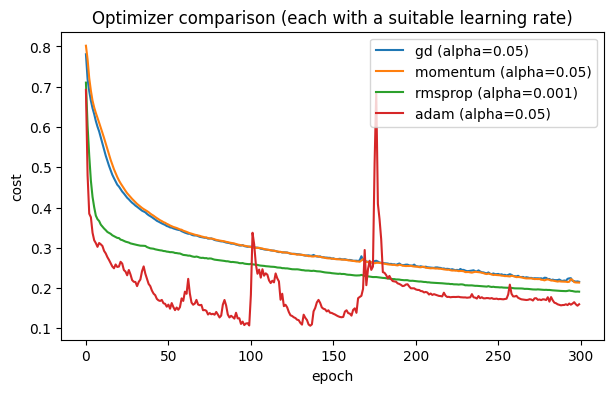

In [24]:
# Unified trainer supporting every optimizer, so the comparison is apples-to-apples
def train_optimizer(X, Y, layer_dims, optimizer="gd", num_epochs=300, alpha=0.05,
                     mini_batch_size=64, beta=0.9, beta1=0.9, beta2=0.999,
                     epsilon=1e-8, seed=1, lr_decay_fn=None):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    costs = []
    t = 0

    if optimizer == "momentum":
        v = initialize_velocity(params)
    elif optimizer == "rmsprop":
        s = initialize_rmsprop(params)
    elif optimizer == "adam":
        v, s = initialize_adam(params)

    for epoch in range(num_epochs):
        current_alpha = lr_decay_fn(alpha, epoch) if lr_decay_fn else alpha
        batches = random_mini_batches(X, Y, mini_batch_size, seed=epoch)
        epoch_cost = 0.0

        for (mb_X, mb_Y) in batches:
            AL, caches = L_model_forward(mb_X, params)
            epoch_cost += compute_cost(AL, mb_Y) * mb_X.shape[1]
            grads = L_model_backward(AL, mb_Y, caches)

            if optimizer == "gd":
                params = update_parameters_gd(params, grads, current_alpha)
            elif optimizer == "momentum":
                params, v = update_parameters_momentum(params, grads, v, beta, current_alpha)
            elif optimizer == "rmsprop":
                params, s = update_parameters_rmsprop(params, grads, s, beta2, current_alpha, epsilon)
            elif optimizer == "adam":
                t += 1
                params, v, s = update_parameters_adam(params, grads, v, s, t, current_alpha,
                                                       beta1, beta2, epsilon)
        costs.append(epoch_cost / X.shape[1])

    return params, costs

dims_opt = [n_x, 10, 5, 1]

# Note: the adaptive optimizers divide by sqrt(s), which effectively AMPLIFIES the step size
# when gradients are small -- so they usually need a smaller alpha than plain GD/momentum.
# Tuning alpha per optimizer is the fair comparison; using one alpha for all would just show
# which optimizer happens to suit that one value.
optimizer_settings = [
    ("gd",       0.05),
    ("momentum", 0.05),
    ("rmsprop",  0.001),
    ("adam",     0.05),
]

plt.figure(figsize=(7, 4))
print(f"{'optimizer':>12} | {'alpha':>7} | {'final cost':>11} | {'dev accuracy':>12}")
print("-" * 52)
for opt, a in optimizer_settings:
    p, c = train_optimizer(X_train, Y_train, dims_opt, optimizer=opt, num_epochs=300, alpha=a)
    acc = np.mean(predict_deep(p, X_dev) == Y_dev) * 100
    print(f"{opt:>12} | {a:>7} | {c[-1]:>11.4f} | {acc:>11.1f}%")
    plt.plot(c, label=f"{opt} (alpha={a})")

plt.xlabel("epoch"); plt.ylabel("cost"); plt.legend()
plt.title("Optimizer comparison (each with a suitable learning rate)")
plt.show()

In [25]:
# Why RMSProp needed a smaller alpha: show what happens at alpha=0.05 for each optimizer
print(f"{'optimizer':>12} | {'alpha=0.001':>12} | {'alpha=0.05':>11}")
print("-" * 40)
for opt in ["gd", "momentum", "rmsprop", "adam"]:
    _, c_small = train_optimizer(X_train, Y_train, dims_opt, optimizer=opt, num_epochs=300, alpha=0.001)
    _, c_large = train_optimizer(X_train, Y_train, dims_opt, optimizer=opt, num_epochs=300, alpha=0.05)
    print(f"{opt:>12} | {c_small[-1]:>12.4f} | {c_large[-1]:>11.4f}")

print("\nRMSProp diverges at alpha=0.05 (cost stuck at ~0.69 = random guessing) because dividing")
print("by sqrt(s) makes its effective steps much larger than the raw alpha suggests. This is a")
print("real practical lesson: 'best optimizer' always depends on also tuning the learning rate.")

   optimizer |  alpha=0.001 |  alpha=0.05
----------------------------------------
          gd |       0.6204 |      0.2155
    momentum |       0.6209 |      0.2136
     rmsprop |       0.1910 |      0.6956
        adam |       0.2431 |      0.1597

RMSProp diverges at alpha=0.05 (cost stuck at ~0.69 = random guessing) because dividing
by sqrt(s) makes its effective steps much larger than the raw alpha suggests. This is a
real practical lesson: 'best optimizer' always depends on also tuning the learning rate.


## 15. Learning Rate Decay

Early in training you want large steps to make fast progress; later you want small steps so the model can settle near a minimum instead of bouncing around it. Learning rate decay reduces $\alpha$ over time. Common schedules:

$$\text{inverse decay: } \alpha = \frac{\alpha_0}{1 + \text{decay\_rate} \times \text{epoch}}$$
$$\text{exponential decay: } \alpha = \alpha_0 \times 0.95^{\text{epoch}}$$
$$\text{square-root decay: } \alpha = \frac{\alpha_0}{\sqrt{\text{epoch}}}$$
$$\text{staircase: drop } \alpha \text{ by a fixed factor every } k \text{ epochs}$$

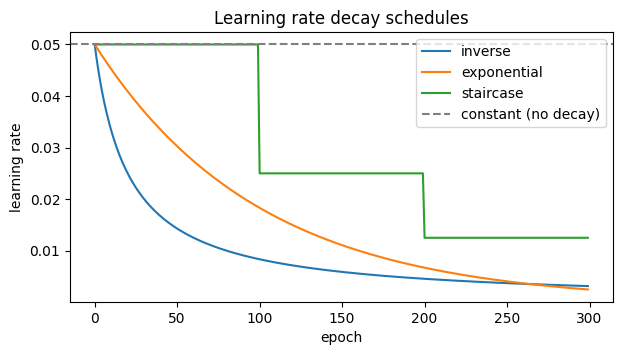

In [26]:
def inverse_decay(alpha0, epoch, decay_rate=0.05):
    return alpha0 / (1 + decay_rate * epoch)

def exponential_decay(alpha0, epoch, k=0.99):
    return alpha0 * (k ** epoch)

def staircase_decay(alpha0, epoch, drop=0.5, every=100):
    return alpha0 * (drop ** (epoch // every))

epochs_axis = np.arange(300)
plt.figure(figsize=(7, 3.5))
for name, fn in [("inverse", inverse_decay), ("exponential", exponential_decay), ("staircase", staircase_decay)]:
    plt.plot(epochs_axis, [fn(0.05, e) for e in epochs_axis], label=name)
plt.axhline(0.05, color="gray", linestyle="--", label="constant (no decay)")
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.legend()
plt.title("Learning rate decay schedules")
plt.show()

        schedule |  final cost | dev accuracy
----------------------------------------------
        constant |      0.1597 |        82.6%
   inverse decay |      0.0887 |        78.0%
exponential decay |      0.0731 |        85.3%


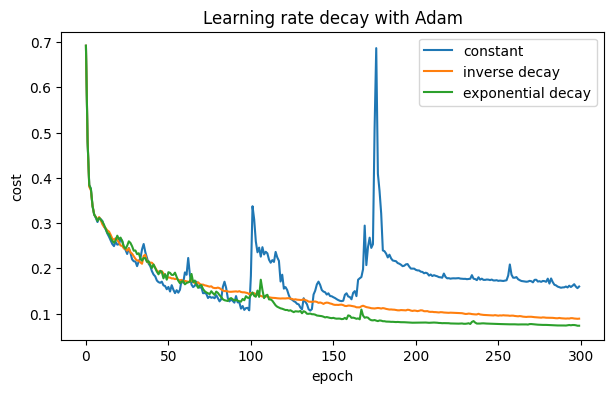

In [27]:
# Does decay actually help? Compare with and without, using Adam
plt.figure(figsize=(7, 4))
print(f"{'schedule':>16} | {'final cost':>11} | {'dev accuracy':>12}")
print("-" * 46)
for name, fn in [("constant", None), ("inverse decay", inverse_decay), ("exponential decay", exponential_decay)]:
    p, c = train_optimizer(X_train, Y_train, dims_opt, optimizer="adam",
                            num_epochs=300, alpha=0.05, lr_decay_fn=fn)
    acc = np.mean(predict_deep(p, X_dev) == Y_dev) * 100
    print(f"{name:>16} | {c[-1]:>11.4f} | {acc:>11.1f}%")
    plt.plot(c, label=name)

plt.xlabel("epoch"); plt.ylabel("cost"); plt.legend()
plt.title("Learning rate decay with Adam")
plt.show()

## 16. Tuning Process

Not all hyperparameters matter equally. A rough priority ordering from practice:

1. **Learning rate $\alpha$** — by far the most important
2. Momentum $\beta$ (~0.9), number of hidden units, mini-batch size
3. Number of layers, learning rate decay schedule
4. Adam's $\beta_1, \beta_2, \varepsilon$ — defaults (0.9, 0.999, $10^{-8}$) are almost always fine

Two key practices:

**Random search beats grid search.** With a grid, if one hyperparameter turns out not to matter, you've wasted an entire axis of your budget re-testing identical values of the one that does. Random sampling explores many more distinct values of *every* hyperparameter for the same number of trials.

**Coarse to fine.** Search broadly first, find a promising region, then sample more densely within it.

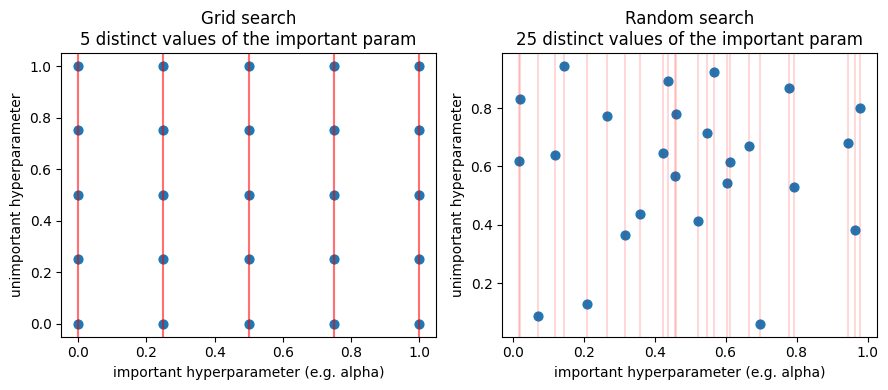

Grid search:   5 distinct values of the x-axis parameter
Random search: 25 distinct values of the x-axis parameter


In [28]:
# Grid vs random: with 25 trials each, how many DISTINCT values of the important parameter get tested?
n_trials = 25
rng = np.random.RandomState(0)

grid_side = int(np.sqrt(n_trials))
grid_x, grid_y = np.meshgrid(np.linspace(0, 1, grid_side), np.linspace(0, 1, grid_side))
grid_points = np.c_[grid_x.ravel(), grid_y.ravel()]
random_points = rng.rand(n_trials, 2)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, pts) in zip(axes, [("Grid search", grid_points), ("Random search", random_points)]):
    ax.scatter(pts[:, 0], pts[:, 1], s=40)
    for x in pts[:, 0]:
        ax.axvline(x, color="red", alpha=0.15)
    ax.set_title(f"{name}\n{len(np.unique(np.round(pts[:,0], 6)))} distinct values of the important param")
    ax.set_xlabel("important hyperparameter (e.g. alpha)")
    ax.set_ylabel("unimportant hyperparameter")
plt.tight_layout()
plt.show()

print(f"Grid search:   {len(np.unique(np.round(grid_points[:,0], 6)))} distinct values of the x-axis parameter")
print(f"Random search: {len(np.unique(np.round(random_points[:,0], 6)))} distinct values of the x-axis parameter")

## 17. Using an Appropriate Scale

Sampling uniformly is wrong for hyperparameters that span orders of magnitude. If you sample $\alpha$ uniformly from $[0.0001, 1]$, about 90% of your samples land in $[0.1, 1]$ — leaving the entire range $[0.0001, 0.1]$ barely explored.

**Use a log scale instead:** sample the exponent uniformly, then exponentiate.

$$r \sim \text{Uniform}[-4, 0], \qquad \alpha = 10^{r}$$

**For $\beta$ (momentum), near 1**, sample $1-\beta$ on a log scale instead, because the difference between 0.9000 and 0.9005 is negligible while 0.999 vs 0.9995 halves the effective averaging window.

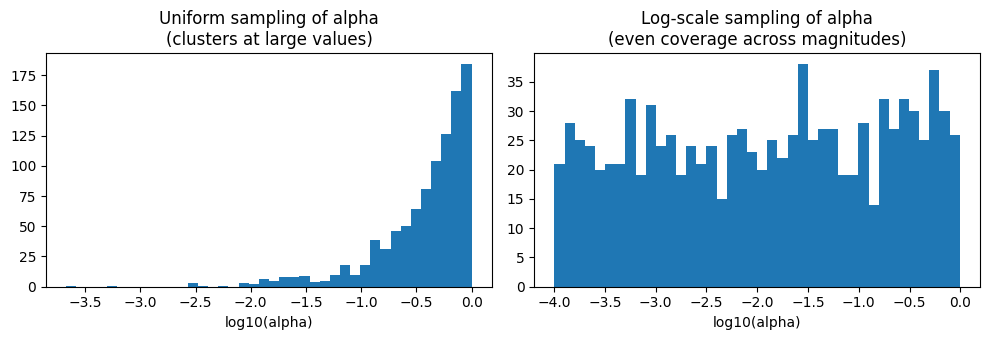

   uniform sampling:   1.0% of samples land below 0.01
 log-scale sampling:  47.1% of samples land below 0.01

Sampled beta values (via 1-beta on a log scale): [0.9437 0.9835 0.9857 0.9961 0.9968]


In [29]:
rng = np.random.RandomState(1)
n_samples = 1000

alpha_uniform = rng.uniform(0.0001, 1, n_samples)
alpha_logscale = 10 ** rng.uniform(-4, 0, n_samples)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(np.log10(alpha_uniform), bins=40)
axes[0].set_title("Uniform sampling of alpha\n(clusters at large values)")
axes[0].set_xlabel("log10(alpha)")
axes[1].hist(np.log10(alpha_logscale), bins=40)
axes[1].set_title("Log-scale sampling of alpha\n(even coverage across magnitudes)")
axes[1].set_xlabel("log10(alpha)")
plt.tight_layout()
plt.show()

for name, samples in [("uniform", alpha_uniform), ("log-scale", alpha_logscale)]:
    frac_small = np.mean(samples < 0.01) * 100
    print(f"{name:>10} sampling: {frac_small:5.1f}% of samples land below 0.01")

# Correct way to sample beta for momentum
r = rng.uniform(-3, -1, 5)          # 1-beta in [0.001, 0.1]
beta_samples = 1 - 10**r
print("\nSampled beta values (via 1-beta on a log scale):", np.round(np.sort(beta_samples), 4))

## 18. Hyperparameter Tuning in Practice

Two working styles, chosen mostly by available compute:

- **"Panda"** — babysit a single model, watching its learning curve day by day and nudging hyperparameters as it trains. Used when compute is scarce relative to model size.
- **"Caviar"** — train many models in parallel with different hyperparameters and pick the winner. Used when you have enough compute to run them simultaneously.

Also worth remembering: **re-evaluate periodically**. Hyperparameters that worked well can go stale as data, architecture, or infrastructure changes.

Below: a complete random search ("caviar" style) over learning rate and mini-batch size, on the housing data, using the log-scale sampling from section 17.

In [30]:
def random_hyperparameter_search(X_tr, Y_tr, X_dv, Y_dv, n_trials=12, seed=0):
    rng = np.random.RandomState(seed)
    results = []

    for trial in range(n_trials):
        alpha = 10 ** rng.uniform(-3, -0.5)                  # log scale, as in section 17
        batch_size = int(rng.choice([16, 32, 64, 128]))
        n_hidden = int(rng.choice([5, 10, 20]))
        beta1 = 1 - 10 ** rng.uniform(-1.5, -0.7)            # ~0.80 to 0.97

        dims = [X_tr.shape[0], n_hidden, max(n_hidden//2, 2), 1]
        params, costs = train_optimizer(X_tr, Y_tr, dims, optimizer="adam",
                                         num_epochs=150, alpha=alpha,
                                         mini_batch_size=batch_size, beta1=beta1, seed=1)
        dev_acc = np.mean(predict_deep(params, X_dv) == Y_dv) * 100
        results.append({
            "trial": trial, "alpha": alpha, "batch": batch_size,
            "hidden": n_hidden, "beta1": beta1,
            "final_cost": costs[-1], "dev_acc": dev_acc
        })

    return pd.DataFrame(results).sort_values("dev_acc", ascending=False)

search_results = random_hyperparameter_search(X_train, Y_train, X_dev, Y_dev, n_trials=12)
print("Random search results (sorted by dev accuracy):\n")
print(search_results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best = search_results.iloc[0]
print(f"\nBest configuration: alpha={best['alpha']:.4f}, batch={int(best['batch'])}, "
      f"hidden={int(best['hidden'])}, beta1={best['beta1']:.3f} -> dev acc {best['dev_acc']:.1f}%")

Random search results (sorted by dev accuracy):

 trial  alpha  batch  hidden  beta1  final_cost  dev_acc
     5 0.0011    128      10 0.8674      0.3174  85.3211
    11 0.0350     64       5 0.9015      0.2437  82.5688
     2 0.0055     16       5 0.9477      0.2562  81.6514
     8 0.0285     32       5 0.9173      0.2258  81.6514
    10 0.0138     64       5 0.9673      0.2758  81.6514
     6 0.1496     64       5 0.8617      0.2797  81.6514
     0 0.0236     32       5 0.9040      0.2808  79.8165
     7 0.0200    128      20 0.8807      0.0149  79.8165
     1 0.0230     32      10 0.9358      0.0468  75.2294
     3 0.0156    128      20 0.9100      0.0304  74.3119
     9 0.0109    128      20 0.8684      0.0308  72.4771
     4 0.2061     32       5 0.9629      0.4927  67.8899

Best configuration: alpha=0.0011, batch=128, hidden=10, beta1=0.867 -> dev acc 85.3%


In [31]:
# Final step of the whole workflow: take the best config, then evaluate ONCE on the untouched test set
best_dims = [n_x, int(best["hidden"]), max(int(best["hidden"])//2, 2), 1]
final_params, final_costs = train_optimizer(X_train, Y_train, best_dims, optimizer="adam",
                                              num_epochs=150, alpha=float(best["alpha"]),
                                              mini_batch_size=int(best["batch"]),
                                              beta1=float(best["beta1"]), seed=1)

train_acc = np.mean(predict_deep(final_params, X_train) == Y_train) * 100
dev_acc   = np.mean(predict_deep(final_params, X_dev) == Y_dev) * 100
test_acc  = np.mean(predict_deep(final_params, X_test) == Y_test) * 100

print(f"Final model  -> train: {train_acc:.1f}%,  dev: {dev_acc:.1f}%,  TEST: {test_acc:.1f}%")
print("\n(The test set was used exactly once, here, after all tuning decisions were made --")
print(" which is what makes this number an unbiased estimate of real-world performance.)")

Final model  -> train: 84.4%,  dev: 85.3%,  TEST: 81.7%

(The test set was used exactly once, here, after all tuning decisions were made --
 which is what makes this number an unbiased estimate of real-world performance.)


## Summary

| Concept | Key idea / formula |
|---|---|
| Normalizing inputs | Subtract train mean, divide by train std; apply same stats to dev/test |
| Vanishing/exploding gradients | Signal compounds exponentially with depth if weights aren't scaled right |
| Weight initialization | He: $\times\sqrt{2/n^{[l-1]}}$ (ReLU); Xavier: $\times\sqrt{1/n^{[l-1]}}$ (tanh) |
| Numerical gradients | Two-sided $\frac{f(\theta+\varepsilon)-f(\theta-\varepsilon)}{2\varepsilon}$, error $O(\varepsilon^2)$ |
| Gradient checking | Relative difference $< 10^{-7}$ = pass; catches real bugs |
| Grad check notes | Debug only; include regularization; turn off dropout; check after some training |
| Mini-batch GD | Update per batch; one pass = one epoch |
| Understanding mini-batch | Batch = smooth/slow; stochastic = noisy/no vectorization; mini-batch = sweet spot |
| Exponentially weighted averages | $v_t = \beta v_{t-1} + (1-\beta)\theta_t$, averages ~$\frac{1}{1-\beta}$ values |
| Understanding EWA | Weights decay exponentially into the past; needs only one variable in memory |
| Bias correction | $v_t / (1-\beta^t)$ fixes the cold start from $v_0=0$ |
| Momentum | EWA of gradients; damps oscillation, accelerates consistent directions |
| RMSProp | EWA of squared gradients; per-parameter adaptive step sizes |
| Adam | Momentum + RMSProp + bias correction; defaults $\beta_1=0.9, \beta_2=0.999$ |
| Learning rate decay | Large steps early, small steps late (inverse / exponential / staircase) |
| Tuning process | $\alpha$ matters most; random search beats grid; coarse to fine |
| Appropriate scale | Sample $\alpha$ as $10^r$; sample $\beta$ via $1-\beta$ on a log scale |
| Tuning in practice | Panda (babysit one) vs caviar (many in parallel); re-evaluate periodically |

The running theme: almost every technique here exists to make gradient descent **stable** (normalization, initialization), **verifiable** (gradient checking), or **faster** (mini-batches, momentum, adaptive rates, decay) — none of them change what the network can represent, only how reliably and quickly it gets there.